# Panda数据处理

In [1]:
import numpy as np
import pandas as pd

## 数据IO操作

### pandas IO操作主要是读取和写入数据，pandas支持多种数据格式的读写操作，包括CSV、Excel、SQL、JSON等。

In [2]:
# 读取 CSV 文件
df = pd.read_csv('csv文件.csv')
df

,姓名,年龄,城市
0,张三,28,北京
1,李四,31,上海
2,王五,25,广州


In [3]:
pd.read_csv("csv文件.csv", header=None)# header=None表示不将第一行作为列名，而是将其作为数据的一部分。

,0,1,2
0,姓名,年龄,城市
1,张三,28,北京
2,李四,31,上海
3,王五,25,广州


In [4]:
pd.read_csv("csv文件.csv", index_col="姓名")# index_col="姓名"表示将"姓名"列作为索引列。

,年龄,城市
姓名,,
张三,28,北京
李四,31,上海
王五,25,广州


#### pd.read_table()函数：读取以制表符（\t）分隔的文本文件，返回一个DataFrame对象。

In [5]:
df = pd.read_table("txt文件.txt", sep="\t", header=None)# sep="\t"表示以制表符（\t）作为分隔符。

In [6]:
df #因为 read_table()函数默认以制表符（\t）作为分隔符，所以可以直接使用read_table()函数读取制表符分隔的文本文件。但是，如果文本文件使用其他分隔符（如逗号、空格等），则需要使用read_csv()函数，并指定sep参数为相应的分隔符。

,0
0,张三 28 北京
1,李四 31 上海
2,王五 25 广州


In [7]:
df = pd.read_table("txt文件.txt", sep=" ", header=None, index_col=0)# index_col=0表示将第一列作为索引列。
df

,1,2
0,,
张三,28,北京
李四,31,上海
王五,25,广州


In [8]:
# 使用read_csv()函数读取制表符分隔的文本文件
df = pd.read_csv("txt文件.txt", sep=" ", header=None)

In [9]:
df

,0,1,2
0,张三,28,北京
1,李四,31,上海
2,王五,25,广州


In [10]:
pd.read_csv("csv文件 copy.csv", sep="-")

,姓名,年龄,城市
0,张三,28,北京
1,李四,31,上海
2,王五,25,广州


In [11]:
pd.read_csv("csv文件 copy 2.csv", sep="\\s+")# sep="\\s+"表示以一个或多个空格作为分隔符。

,姓名,年龄,城市
0,张三,28,北京
1,李四,31,上海
2,王五,25,广州


### excel读取

In [12]:
data1 =  pd.read_excel('excel文件.xlsx')# 读取 Excel 文件,默认读取第一个工作表。
data1

,编号,名称,数值
0,1,数据1,10
1,2,数据2,20
2,3,数据3,30
3,4,数据4,40
4,5,数据5,50


In [13]:
data2 = pd.read_excel('excel文件.xlsx', sheet_name='Sheet2')# 读取 Excel 文件的指定工作表。
data2

,编号,名称,数值
0,1,项目1,15
1,2,项目2,25
2,3,项目3,35
3,4,项目4,45
4,5,项目5,55


In [14]:
data1.to_excel('output.xlsx', index=False)# 将 DataFrame 保存为 Excel 文件，index=False表示不保存索引列。

In [15]:
data1.to_csv('output.csv', index=False)# 将 DataFrame 保存为 CSV 文件，index=False表示不保存索引列。

## 数据探索

- describe()函数：用于快速查看数据的统计信息，包括计数、均值、标准差、最小值、最大值等。
- info()函数：用于查看数据的基本信息，包括数据类型、非空值数量、内存占用等。
- tail()函数：用于查看数据的最后几行，默认显示最后5行。
- sample()函数：用于随机抽样数据，可以指定抽样的数量或比例。

In [16]:
df = pd.DataFrame(data=np.random.randint(1, 10000, size=(1000, 5)), columns=['A', 'B', 'C', 'D', 'E'])# 创建一个包含1000行、5列的随机整数数据的DataFrame，整数范围为1到9999。
df

,A,B,C,D,E
0,5263,5159,5991,6209,7382
1,541,667,7949,8129,7323
2,3725,7810,3382,5659,8469
3,5898,3915,6978,9661,4479
4,2239,8426,3603,7663,3351
...,...,...,...,...,...
995,963,2586,27,1260,8251
996,2940,3375,1009,3575,401
997,8491,5320,9788,7541,8261
998,2592,4217,7184,675,6095


In [17]:
df.describe(percentiles=[.25, .5, .75, .99])# describe()函数用于快速查看数据的统计信息，包括计数、均值、标准差、最小值、最大值等。percentiles参数用于指定要计算的分位数。

,A,B,C,D,E
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,5072.927000,5141.509000,4885.79900,4986.980000,4928.20800
std,2886.328243,2817.082333,2984.46132,2908.350183,2883.31737
min,26.000000,73.000000,27.00000,6.000000,5.00000
25%,2664.500000,2803.250000,2265.50000,2385.250000,2473.75000
50%,5088.000000,5166.000000,4892.50000,4885.000000,4790.00000
75%,7605.000000,7685.250000,7541.75000,7552.000000,7484.50000
99%,9837.190000,9867.270000,9899.12000,9880.010000,9876.09000
max,9984.000000,9995.000000,9999.00000,9987.000000,9997.00000


In [18]:
df.info()# info()函数用于查看DataFrame的基本信息，包括数据类型、非空值数量、内存占用等。

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       1000 non-null   int64
 1   B       1000 non-null   int64
 2   C       1000 non-null   int64
 3   D       1000 non-null   int64
 4   E       1000 non-null   int64
dtypes: int64(5)
memory usage: 39.2 KB


In [19]:
df.head()# head()函数用于查看数据的前几行，默认显示前5行。

,A,B,C,D,E
0,5263,5159,5991,6209,7382
1,541,667,7949,8129,7323
2,3725,7810,3382,5659,8469
3,5898,3915,6978,9661,4479
4,2239,8426,3603,7663,3351


In [20]:
df.tail(n = 10)# tail()函数用于查看数据的最后几行，n参数指定显示的行数，默认显示最后5行。

,A,B,C,D,E
990,9833,85,5177,2988,2810
991,5176,1825,3484,9246,983
992,9673,5683,7990,1853,4564
993,8811,3463,3409,5413,4888
994,9966,5729,7410,296,2307
995,963,2586,27,1260,8251
996,2940,3375,1009,3575,401
997,8491,5320,9788,7541,8261
998,2592,4217,7184,675,6095
999,4097,3695,2243,4102,8822


In [21]:
df.sample(n=5)# sample()函数用于随机抽样数据，n参数指定抽样的数量。

,A,B,C,D,E
174,6623,8614,695,105,3650
976,1847,5658,1526,3523,6469
366,8827,9067,5109,8584,873
110,6556,9184,4346,1427,4204
84,9058,7369,7963,8149,8711


## 空值处理

### None

- None是Python中的一个特殊对象，表示空值。其类型为python object。因此，None不能参与到数值计算中，也不能与其他类型进行比较操作。
- object类型的运算要比数值类型的运算慢很多，因此在数据分析中，尽量避免使用object类型的数据。

In [22]:
type(None)

NoneType

## np.nan(NaN)

- np.nan是NumPy库中的一个特殊浮点数，表示“不是一个数字”（Not a Number）。它通常用于表示缺失或无效的数值数据。与None不同，np.nan是一个浮点数类型，可以参与数值计算，但在计算中会被视为缺失值(NaN)。
- 在numpy和pandas中，可以使用np.nanxxx()函数来处理NaN值，此时视nan为0。
- 因为np.nan是一个浮点数类型，所以在数据分析中，尽量使用np.nan来表示缺失值，而不是None。

In [23]:
type(np.nan)

float

In [24]:
def getsum(x):
    return x.sum()

In [25]:
data1 = np.arange(1, 10000001, dtype=object)

In [26]:
%timeit getsum(data1)

81.7 ms ± 988 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [27]:
data2 = np.arange(1, 10000001, dtype=np.float64)

In [28]:
%timeit getsum(data2)

1.32 ms ± 61.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### pandas自动把None转换为np.nan

In [29]:
df = pd.DataFrame(data=np.random.randint(0, 10, size=(3, 5)), columns=['A', 'B', 'C', 'D', 'E'])# 创建一个包含100行5列的随机数DataFrame，列名为'A'、'B'、'C'、'D'和'E'。

In [30]:
df

,A,B,C,D,E
0,4,0,0,2,0
1,0,4,5,2,7
2,5,1,0,2,9


In [31]:
df.loc[2] = None# loc[]函数用于根据标签选择数据，df.loc[2]表示选择索引为2的行。将其赋值为None表示将该行的所有列的值都设置为缺失值。

In [32]:
df

,A,B,C,D,E
0,4.0,0.0,0.0,2.0,0.0
1,0.0,4.0,5.0,2.0,7.0
2,NaN,NaN,NaN,NaN,NaN


> NaN 是一个符号，表示“不是一个数字”（Not a Number），不是一个具体的数值。   
> 在pandas中，None和np.nan 都会被显示为缺失值(NaN).  

### 空值查找

- isnull()函数：用于判断数据是否为缺失值(NaN)，返回一个布尔型的DataFrame或Series对象，缺失值为True，非缺失值为False。
- notnull()函数：用于判断数据是否为非缺失值，返回一个布尔型的DataFrame或Series对象，非缺失值为True，缺失值为False。

In [33]:
df

,A,B,C,D,E
0,4.0,0.0,0.0,2.0,0.0
1,0.0,4.0,5.0,2.0,7.0
2,NaN,NaN,NaN,NaN,NaN


In [34]:
df.isnull()# isnull()函数用于判断数据是否为缺失值(NaN)，返回一个布尔型的DataFrame或Series对象，缺失值为True，非缺失值为False。

,A,B,C,D,E
0,False,False,False,False,False
1,False,False,False,False,False
2,True,True,True,True,True


- any()函数：用于检查DataFrame或Series中是否存在任何True值。如果存在至少一个True值，返回True；否则返回False。默认情况下，any()函数沿着列方向（axis=0）进行操作，即检查每一列是否存在True值。如果希望沿着行方向（axis=1）进行操作，可以通过设置参数axis=1来实现。
- all()函数：用于检查DataFrame或Series中是否所有值都为True。如果所有值都为True，返回True；否则返回False。默认情况下，all()函数沿着列方向（axis=0）进行操作，即检查每一列是否所有值都为True。如果希望沿着行方向（axis=1）进行操作，可以通过设置参数axis=1来实现。

In [35]:
df.isnull().any()# any()函数用于检查DataFrame或Series中是否存在任何True值。如果存在至少一个True值，返回True；否则返回False。默认情况下，any()函数沿着列方向（axis=0）进行操作，即检查每一列是否存在True值。

A    True
B    True
C    True
D    True
E    True
dtype: bool

In [36]:
df.isnull().any(axis=1)# all()函数用于检查DataFrame或Series中是否所有值都为True。如果所有值都为True，返回True；否则返回False。默认情况下，all()函数沿着列方向（axis=0）进行操作，即检查每一列是否所有值都为True。如果希望沿着行方向（axis=1）进行操作，可以通过设置参数axis=1来实现。

0    False
1    False
2     True
dtype: bool

In [37]:
# 找出至少包含一个缺失值的行
df[df.isnull().any(axis=1)]# df.isnull().any(axis=1)返回一个布尔型的Series对象，表示每一行是否包含至少一个缺失值。然后使用布尔索引df[...]选择出包含至少一个缺失值的行

,A,B,C,D,E
2,NaN,NaN,NaN,NaN,NaN


In [38]:
# 找出至少包含一个缺失值的列
df.loc[:, df.isnull().any()]# df.isnull().any()返回一个布尔型的Series对象，表示每一列是否包含至少一个缺失值。然后使用布尔索引df.loc[:, ...]选择出包含至少一个缺失值的列

,A,B,C,D,E
0,4.0,0.0,0.0,2.0,0.0
1,0.0,4.0,5.0,2.0,7.0
2,NaN,NaN,NaN,NaN,NaN


In [39]:
df.notnull()# notnull()函数用于判断数据是否为非缺失值，返回一个布尔型的DataFrame或Series对象，非缺失值为True，缺失值为False。

,A,B,C,D,E
0,True,True,True,True,True
1,True,True,True,True,True
2,False,False,False,False,False


In [40]:
df.notnull().all(axis=1)# all()函数用于检查DataFrame或Series中是否所有值都为True。如果所有值都为True，返回True；否则返回False。默认情况下，all()函数沿着列方向（axis=0）进行操作，即检查每一列是否所有值都为True。

0     True
1     True
2    False
dtype: bool

In [41]:
# 取出所有非缺失值的行
df[df.notnull().all(axis=1)]# df.notnull().all(axis=1)返回一个布尔型的Series对象，表示每一行是否所有值都为非缺失值。然后使用布尔索引df[...]选择出所有非缺失值的行

,A,B,C,D,E
0,4.0,0.0,0.0,2.0,0.0
1,0.0,4.0,5.0,2.0,7.0


In [42]:
# 查看某一列的空值占比
df.isnull().mean()# isnull()函数用于判断数据是否为缺失值(NaN)，返回一个布尔型的DataFrame或Series对象，缺失值为True，非缺失值为False。mean()函数用于计算每一列的平均值，即空值占比。 

A    0.333333
B    0.333333
C    0.333333
D    0.333333
E    0.333333
dtype: float64

> 列字段是不能轻易删除的

### 空值填充

fillna()函数：用于填充缺失值(NaN)，可以指定填充值或使用前一个/后一个有效值进行填充。

In [43]:
df

,A,B,C,D,E
0,4.0,0.0,0.0,2.0,0.0
1,0.0,4.0,5.0,2.0,7.0
2,NaN,NaN,NaN,NaN,NaN


In [44]:
df.fillna(value=0)# fillna()函数用于填充缺失值(NaN)，可以指定填充值或使用前一个/后一个有效值进行填充。

,A,B,C,D,E
0,4.0,0.0,0.0,2.0,0.0
1,0.0,4.0,5.0,2.0,7.0
2,0.0,0.0,0.0,0.0,0.0


In [45]:
df.mean()# mean()函数用于计算每一列的均值，返回一个包含每一列均值的Series对象。

A    2.0
B    2.0
C    2.5
D    2.0
E    3.5
dtype: float64

In [46]:
# 使用均值来填充缺失值
df.fillna(value=df.mean())# df.mean()计算每一列的均值，然后使用fillna()函数将缺失值填充为对应列的均值。

,A,B,C,D,E
0,4.0,0.0,0.0,2.0,0.0
1,0.0,4.0,5.0,2.0,7.0
2,2.0,2.0,2.5,2.0,3.5


In [47]:
df = pd.DataFrame(data=np.random.randint(0, 100, size=(10,3)), columns=['A', 'B', 'C'])# 创建一个包含10行3列的随机整数数据的DataFrame，整数范围为0到99。

In [48]:
df

,A,B,C
0,11,26,98
1,8,38,8
2,36,58,79
3,63,98,21
4,44,70,18
5,19,88,67
6,19,4,29
7,49,23,57
8,86,58,40
9,59,56,25


In [49]:
df.loc[3, 'B'] = None# loc[]函数用于根据标签选择数据，df.loc[3, 'B']表示选择索引为3的行和列名为'B'的列。将其赋值为None表示将该单元格的值设置为缺失值。
df.loc[5, 'C'] = None# loc[]函数用于根据标签选择数据，df.loc[5, 'C']表示选择索引为5的行和列名为'C'的列。将其赋值为None表示将该单元格的值设置为缺失值。
df.loc[9] = None# loc[]函数用于根据标签选择数据，df.loc[9]表示选择索引为9的行。将其赋值为None表示将该行的所有列的值都设置为缺失值。

In [50]:
df

,A,B,C
0,11.0,26.0,98.0
1,8.0,38.0,8.0
2,36.0,58.0,79.0
3,63.0,NaN,21.0
4,44.0,70.0,18.0
5,19.0,88.0,NaN
6,19.0,4.0,29.0
7,49.0,23.0,57.0
8,86.0,58.0,40.0
9,NaN,NaN,NaN


In [51]:
df.mean(axis=1)# mean()函数用于计算每一列的均值，返回一个包含每一列均值的Series对象。

0    45.000000
1    18.000000
2    57.666667
3    42.000000
4    44.000000
5    53.500000
6    17.333333
7    43.000000
8    61.333333
9          NaN
dtype: float64

In [52]:
df.fillna(value=df.mean(axis=1), axis=1)# fillna()函数用于填充缺失值(NaN)，可以指定填充值或使用前一个/后一个有效值进行填充。value=df.mean(axis=1)表示使用每一行的均值来填充缺失值，axis=0表示沿着列方向进行填充。

,A,B,C
0,11.0,26.0,98.0
1,8.0,38.0,8.0
2,36.0,58.0,79.0
3,63.0,42.0,21.0
4,44.0,70.0,18.0
5,19.0,88.0,53.5
6,19.0,4.0,29.0
7,49.0,23.0,57.0
8,86.0,58.0,40.0
9,NaN,NaN,NaN


In [53]:
# 使用临近值填充
df.ffill(axis=1)# ffill()函数用于使用前一个有效值来填充缺失值(NaN)，axis=1表示沿着行方向进行填充，即使用每一行的前一个有效值来填充缺失值。

,A,B,C
0,11.0,26.0,98.0
1,8.0,38.0,8.0
2,36.0,58.0,79.0
3,63.0,63.0,21.0
4,44.0,70.0,18.0
5,19.0,88.0,88.0
6,19.0,4.0,29.0
7,49.0,23.0,57.0
8,86.0,58.0,40.0
9,NaN,NaN,NaN


In [54]:
# 向后填充
df.bfill(axis=0)# bfill()函数用于使用后一个有效值来填充缺失值(NaN)，axis=1表示沿着行方向进行填充，即使用每一行的后一个有效值来填充缺失值。

,A,B,C
0,11.0,26.0,98.0
1,8.0,38.0,8.0
2,36.0,58.0,79.0
3,63.0,70.0,21.0
4,44.0,70.0,18.0
5,19.0,88.0,29.0
6,19.0,4.0,29.0
7,49.0,23.0,57.0
8,86.0,58.0,40.0
9,NaN,NaN,NaN


In [55]:
df

,A,B,C
0,11.0,26.0,98.0
1,8.0,38.0,8.0
2,36.0,58.0,79.0
3,63.0,NaN,21.0
4,44.0,70.0,18.0
5,19.0,88.0,NaN
6,19.0,4.0,29.0
7,49.0,23.0,57.0
8,86.0,58.0,40.0
9,NaN,NaN,NaN


### 空值过滤

dropna()函数：用于删除缺失值(NaN)所在的行或列。可以通过设置参数axis=0或axis=1来指定删除行或列，默认情况下删除行。

In [56]:
df

,A,B,C
0,11.0,26.0,98.0
1,8.0,38.0,8.0
2,36.0,58.0,79.0
3,63.0,NaN,21.0
4,44.0,70.0,18.0
5,19.0,88.0,NaN
6,19.0,4.0,29.0
7,49.0,23.0,57.0
8,86.0,58.0,40.0
9,NaN,NaN,NaN


In [57]:
df.notnull()# isnull()函数用于判断数据是否为缺失值(NaN)，返回一个布尔型的DataFrame或Series对象，缺失值为True，非缺失值为False。

,A,B,C
0,True,True,True
1,True,True,True
2,True,True,True
3,True,False,True
4,True,True,True
5,True,True,False
6,True,True,True
7,True,True,True
8,True,True,True
9,False,False,False


In [58]:
df.notnull().any(axis=1)# all()函数用于检查DataFrame或Series中是否所有值都为True。如果所有值都为True，返回True；否则返回False。默认情况下，all()函数沿着列方向（axis=0）进行操作，即检查每一列是否所有值都为True。如果希望沿着行方向（axis=1）进行操作，可以通过设置参数axis=1来实现。

0     True
1     True
2     True
3     True
4     True
5     True
6     True
7     True
8     True
9    False
dtype: bool

In [59]:
df.loc[df.notnull().any(axis=1)]# df.notnull().all(axis=1)返回一个布尔型的Series对象，表示每一行是否所有值都为非缺失值。然后使用布尔索引df.loc[...]选择出所有值都为非缺失值的行。

,A,B,C
0,11.0,26.0,98.0
1,8.0,38.0,8.0
2,36.0,58.0,79.0
3,63.0,NaN,21.0
4,44.0,70.0,18.0
5,19.0,88.0,NaN
6,19.0,4.0,29.0
7,49.0,23.0,57.0
8,86.0,58.0,40.0


In [60]:
# 过滤掉A列中包含缺失值的行
df['A']

0    11.0
1     8.0
2    36.0
3    63.0
4    44.0
5    19.0
6    19.0
7    49.0
8    86.0
9     NaN
Name: A, dtype: float64

In [61]:
df['A'].notnull()# notnull()函数用于判断数据是否为非缺失值，返回一个布尔型的Series对象，非缺失值为True，缺失值为False。

0     True
1     True
2     True
3     True
4     True
5     True
6     True
7     True
8     True
9    False
Name: A, dtype: bool

In [62]:
df.loc[df['A'].notnull()]

,A,B,C
0,11.0,26.0,98.0
1,8.0,38.0,8.0
2,36.0,58.0,79.0
3,63.0,NaN,21.0
4,44.0,70.0,18.0
5,19.0,88.0,NaN
6,19.0,4.0,29.0
7,49.0,23.0,57.0
8,86.0,58.0,40.0


- df.dropna()函数：删除所有包含缺失值的行，返回一个新的DataFrame对象。

In [63]:
df

,A,B,C
0,11.0,26.0,98.0
1,8.0,38.0,8.0
2,36.0,58.0,79.0
3,63.0,NaN,21.0
4,44.0,70.0,18.0
5,19.0,88.0,NaN
6,19.0,4.0,29.0
7,49.0,23.0,57.0
8,86.0,58.0,40.0
9,NaN,NaN,NaN


In [64]:
df.dropna()# dropna()函数用于删除所有包含缺失值的行，返回一个新的DataFrame对象。  

,A,B,C
0,11.0,26.0,98.0
1,8.0,38.0,8.0
2,36.0,58.0,79.0
4,44.0,70.0,18.0
6,19.0,4.0,29.0
7,49.0,23.0,57.0
8,86.0,58.0,40.0


In [65]:
df.dropna(how='all')# dropna()函数用于删除所有包含缺失值的行，返回一个新的DataFrame对象。how='all'表示只删除所有值都为缺失值的行。

,A,B,C
0,11.0,26.0,98.0
1,8.0,38.0,8.0
2,36.0,58.0,79.0
3,63.0,NaN,21.0
4,44.0,70.0,18.0
5,19.0,88.0,NaN
6,19.0,4.0,29.0
7,49.0,23.0,57.0
8,86.0,58.0,40.0


In [66]:
df.dropna(how='any', subset=['A', 'B'])# dropna()函数用于删除所有包含缺失值的行，返回一个新的DataFrame对象。how='any'表示只要有一个值为缺失值就删除该行。subset=['A', 'B']表示只考虑'A'和'B'列。

,A,B,C
0,11.0,26.0,98.0
1,8.0,38.0,8.0
2,36.0,58.0,79.0
4,44.0,70.0,18.0
5,19.0,88.0,NaN
6,19.0,4.0,29.0
7,49.0,23.0,57.0
8,86.0,58.0,40.0


## 异常值处理

### 异常值分析

#### 异常值是指在数据集中明显偏离其他观测值的数值。异常值可能是由于数据录入错误、测量误差或真实的极端情况引起的。在数据分析中，异常值可能会对统计分析和模型训练产生不利影响，因此需要进行处理。

- 使用describe()函数查看每一列的统计信息，包括均值、标准差、最小值、最大值等，可以帮助我们识别异常值。

### 异常值的认定

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 不符合业务逻辑的异常值->直接过滤掉就行

### 使用均值和标准差识别异常值

数据要先满足服从标准正态分布。  
abs(X) > 3 * X.std()

In [68]:
df = pd.DataFrame(np.random.randn(10000,4), columns=['A','B','C','D'])

In [69]:
df

,A,B,C,D
0,-0.481319,-1.705973,0.062252,1.609364
1,0.589795,-1.342311,-1.381050,1.224498
2,1.967056,-0.777903,-1.226106,0.106283
3,1.014068,1.524542,1.265789,0.780331
4,1.197573,1.379422,-1.528721,-1.685383
...,...,...,...,...
9995,0.178553,-0.293337,0.528337,-0.893198
9996,0.802637,-0.431702,0.873807,-0.255202
9997,-0.167949,0.851514,-0.156281,-0.527580
9998,0.691394,-1.094799,1.225796,0.915875


<Axes: xlabel='A', ylabel='Count'>

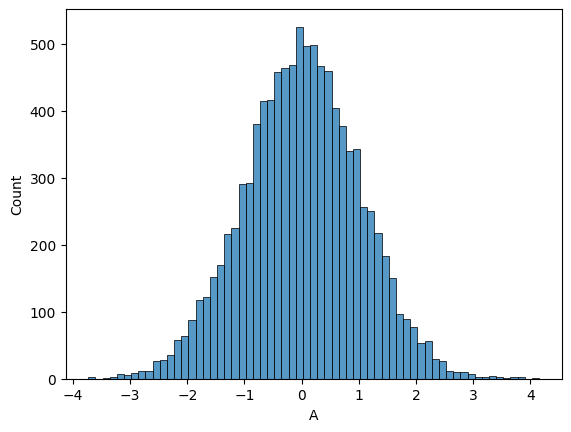

In [70]:
sns.histplot(data=df, x='A')

In [71]:
df.std()# std()函数用于计算每一列的标准差，返回一个包含每一列标准差的Series对象。

A    1.012295
B    0.995072
C    0.998070
D    0.993103
dtype: float64

In [72]:
df

,A,B,C,D
0,-0.481319,-1.705973,0.062252,1.609364
1,0.589795,-1.342311,-1.381050,1.224498
2,1.967056,-0.777903,-1.226106,0.106283
3,1.014068,1.524542,1.265789,0.780331
4,1.197573,1.379422,-1.528721,-1.685383
...,...,...,...,...
9995,0.178553,-0.293337,0.528337,-0.893198
9996,0.802637,-0.431702,0.873807,-0.255202
9997,-0.167949,0.851514,-0.156281,-0.527580
9998,0.691394,-1.094799,1.225796,0.915875


In [73]:
np.abs(df)# abs()函数用于计算每个元素的绝对值，返回一个新的DataFrame对象。

,A,B,C,D
0,0.481319,1.705973,0.062252,1.609364
1,0.589795,1.342311,1.381050,1.224498
2,1.967056,0.777903,1.226106,0.106283
3,1.014068,1.524542,1.265789,0.780331
4,1.197573,1.379422,1.528721,1.685383
...,...,...,...,...
9995,0.178553,0.293337,0.528337,0.893198
9996,0.802637,0.431702,0.873807,0.255202
9997,0.167949,0.851514,0.156281,0.527580
9998,0.691394,1.094799,1.225796,0.915875


In [74]:
np.abs(df) > 3 * df.std()# abs()函数用于计算每个元素的绝对值，返回一个新的DataFrame对象。df.std()计算每一列的标准差，返回一个包含每一列标准差的Series对象。然后将每个元素的绝对值与对应列的标准差乘以3进行比较，返回一个布尔型的DataFrame对象，表示每个元素是否大于3倍标准差。

,A,B,C,D
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
9995,False,False,False,False
9996,False,False,False,False
9997,False,False,False,False
9998,False,False,False,False


In [75]:
exp_condition = (np.abs(df) > 3 * df.std()).any(axis=1)# any()函数用于检查DataFrame或Series中是否存在任何True值。如果存在至少一个True值，返回True；否则返回False。默认情况下，any()函数沿着列方向（axis=0）进行操作，即检查每一列是否存在True值。如果希望沿着行方向（axis=1）进行操作，可以通过设置参数axis=1来实现。

In [76]:
exp_condition

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [77]:
df.loc[exp_condition]

,A,B,C,D
158,0.244308,-0.454488,-3.719112,1.410769
205,-0.097309,4.047724,0.340191,1.725306
206,0.555591,0.029326,0.346774,-3.123619
325,-0.409723,-0.076085,-3.376650,-1.093281
424,-0.823913,-0.127266,-3.526213,-0.036394
...,...,...,...,...
9655,1.345894,3.304619,-0.755425,0.831979
9679,3.869246,-0.870075,-0.573401,0.762025
9755,0.544424,0.011346,0.464900,-3.503375
9857,0.484245,0.158985,-3.533216,0.066225


In [78]:
normal_condition = ~exp_condition# ~运算符用于对布尔型的Series对象进行取反操作，即将True变为False，False变为True。
normal_condition

0       True
1       True
2       True
3       True
4       True
        ... 
9995    True
9996    True
9997    True
9998    True
9999    True
Length: 10000, dtype: bool

In [79]:
df.loc[normal_condition] # 过滤掉异常值

,A,B,C,D
0,-0.481319,-1.705973,0.062252,1.609364
1,0.589795,-1.342311,-1.381050,1.224498
2,1.967056,-0.777903,-1.226106,0.106283
3,1.014068,1.524542,1.265789,0.780331
4,1.197573,1.379422,-1.528721,-1.685383
...,...,...,...,...
9995,0.178553,-0.293337,0.528337,-0.893198
9996,0.802637,-0.431702,0.873807,-0.255202
9997,-0.167949,0.851514,-0.156281,-0.527580
9998,0.691394,-1.094799,1.225796,0.915875


#### df.dropna()函数：删除所有包含缺失值的行，返回一个新的DataFrame对象。

In [80]:
df.loc[exp_condition].index

Index([ 158,  205,  206,  325,  424,  630,  681,  908, 1027, 1133,
       ...
       9250, 9380, 9414, 9443, 9654, 9655, 9679, 9755, 9857, 9920],
      dtype='int64', length=114)

In [81]:
df.drop(labels=df.loc[exp_condition].index, axis=0)# drop()函数用于删除指定的行或列，labels参数指定要删除的行或列的标签，axis=0表示删除行，inplace=True表示在原DataFrame上进行修改。

,A,B,C,D
0,-0.481319,-1.705973,0.062252,1.609364
1,0.589795,-1.342311,-1.381050,1.224498
2,1.967056,-0.777903,-1.226106,0.106283
3,1.014068,1.524542,1.265789,0.780331
4,1.197573,1.379422,-1.528721,-1.685383
...,...,...,...,...
9995,0.178553,-0.293337,0.528337,-0.893198
9996,0.802637,-0.431702,0.873807,-0.255202
9997,-0.167949,0.851514,-0.156281,-0.527580
9998,0.691394,-1.094799,1.225796,0.915875


#### 使用上四分位数和下四分位数识别异常值

In [82]:
order = pd.read_excel('电商用户数据.xlsx')# 读取 Excel 文件,默认读取第一个工作表。

In [83]:
order

,买家昵称,付款日期,订单状态,实付金额,邮费,省份,城市,购买数量
0,山月同学0001,2025-04-20 16:40:39.796,交易成功,859.25,0,江苏,南通,5
1,南瓜同学0002,2025-12-19 01:09:57.045,交易成功,1683.73,0,安徽,合肥,5
2,青柚买手0003,2025-03-13 05:21:31.262,待发货,1646.42,0,浙江,嘉兴,5
3,山月生活家0004,2025-10-31 22:10:53.222,交易成功,387.61,0,湖南,长沙,5
4,海风优选0005,2025-07-21 02:12:22.722,交易成功,523.95,0,重庆,重庆,5
...,...,...,...,...,...,...,...,...
995,柠檬生活家0996,2026-02-23 21:07:49.775,交易成功,164.59,0,江苏,常州,1
996,山月会员0997,2026-03-11 07:31:03.859,交易关闭,114.29,0,陕西,渭南,1
997,松果生活家0998,2025-09-01 22:27:36.453,交易成功,375.58,0,湖南,岳阳,4
998,星河掌柜0999,2025-06-03 02:54:00.463,交易成功,394.92,0,福建,莆田,4


In [84]:
order.info()# info()函数用于查看DataFrame的基本信息，包括数据类型、非空值数量、内存占用等。

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   买家昵称    1000 non-null   str           
 1   付款日期    1000 non-null   datetime64[us]
 2   订单状态    1000 non-null   str           
 3   实付金额    1000 non-null   float64       
 4   邮费      1000 non-null   int64         
 5   省份      1000 non-null   str           
 6   城市      1000 non-null   str           
 7   购买数量    1000 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 62.6 KB


In [85]:
order.describe(percentiles=[0.25, 0.5, 0.75, 0.99])# describe()函数用于快速查看数据的统计信息，包括计数、均值、标准差、最小值、最大值等。

,付款日期,实付金额,邮费,购买数量
count,1000,1000.000000,1000.000000,1000.000000
mean,2025-10-13 09:13:17.003573,567.940150,0.504000,3.009000
min,2024-12-31 17:48:41.019000,20.620000,0.000000,1.000000
25%,2025-05-29 00:49:57.618250,237.607500,0.000000,2.000000
50%,2025-10-11 16:00:28.524000,449.355000,0.000000,3.000000
75%,2026-02-26 15:49:10.699500,832.845000,0.000000,4.000000
99%,2026-07-04 05:16:05.670370,1683.800500,12.000000,5.000000
max,2026-07-09 00:13:15.288000,1856.050000,12.000000,5.000000
std,NaN,421.772901,2.083825,1.412414


<Axes: ylabel='实付金额'>

/Users/wangbaole/Desktop/Code/data-analysis/.venv/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/wangbaole/Desktop/Code/data-analysis/.venv/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 20184 (\N{CJK UNIFIED IDEOGRAPH-4ED8}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/wangbaole/Desktop/Code/data-analysis/.venv/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 37329 (\N{CJK UNIFIED IDEOGRAPH-91D1}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/wangbaole/Desktop/Code/data-analysis/.venv/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 39069 (\N{CJK UNIFIED IDEOGRAPH-989D}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/wangbaole/Desktop/Code/data-analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:17

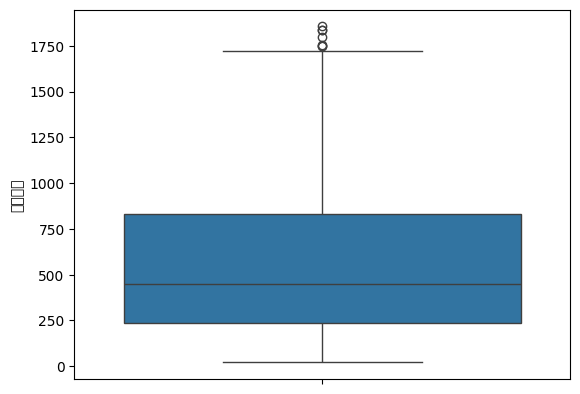

In [86]:
sns.boxplot(y= order['实付金额'])# boxplot()函数用于绘制箱线图，显示数据的分布情况，包括中位数、四分位数、异常值等。

- BOTTOM = Q1 - 1.5 * IQR
- UPPER = Q3 + 1.5 * IQR

In [87]:
Q1, Q3 = np.quantile(order['实付金额'], q=[0.25, 0.75])# quantile()函数用于计算指定分位数的值，q参数指定要计算的分位数。
IQR = Q3 - Q1
BOTTOM = Q1 - 1.5 * IQR
UPPER = Q3 + 1.5 * IQR

In [88]:
order['实付金额']> UPPER

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Name: 实付金额, Length: 1000, dtype: bool

In [89]:
order['实付金额']< BOTTOM

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Name: 实付金额, Length: 1000, dtype: bool

In [90]:
exp_condition = (order['实付金额']>UPPER)| (order['实付金额']<BOTTOM)
exp_condition

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Name: 实付金额, Length: 1000, dtype: bool

In [91]:
order.loc[exp_condition]

,买家昵称,付款日期,订单状态,实付金额,邮费,省份,城市,购买数量
97,南瓜优选0098,2026-03-27 12:39:04.560,交易成功,1747.34,0,北京,北京,5
429,海风买手0430,2025-10-08 22:03:06.788,已付款,1856.05,0,河北,保定,5
430,白茶优选0431,2025-06-22 14:44:01.148,退款成功,1835.17,0,广东,佛山,5
649,青柚用户0650,2025-04-28 07:43:51.329,退款成功,1837.28,0,湖北,襄阳,5
668,柠檬会员0669,2025-03-03 21:36:19.109,交易成功,1755.85,0,广东,珠海,5
689,南瓜达人0690,2025-04-27 09:06:08.848,已付款,1749.36,0,四川,德阳,5
707,白茶用户0708,2025-09-26 00:53:39.830,已发货,1799.64,0,安徽,安庆,5


In [92]:
order.loc[exp_condition].index

Index([97, 429, 430, 649, 668, 689, 707], dtype='int64')

In [93]:
order.drop(labels=order.loc[exp_condition].index, axis=0)

,买家昵称,付款日期,订单状态,实付金额,邮费,省份,城市,购买数量
0,山月同学0001,2025-04-20 16:40:39.796,交易成功,859.25,0,江苏,南通,5
1,南瓜同学0002,2025-12-19 01:09:57.045,交易成功,1683.73,0,安徽,合肥,5
2,青柚买手0003,2025-03-13 05:21:31.262,待发货,1646.42,0,浙江,嘉兴,5
3,山月生活家0004,2025-10-31 22:10:53.222,交易成功,387.61,0,湖南,长沙,5
4,海风优选0005,2025-07-21 02:12:22.722,交易成功,523.95,0,重庆,重庆,5
...,...,...,...,...,...,...,...,...
995,柠檬生活家0996,2026-02-23 21:07:49.775,交易成功,164.59,0,江苏,常州,1
996,山月会员0997,2026-03-11 07:31:03.859,交易关闭,114.29,0,陕西,渭南,1
997,松果生活家0998,2025-09-01 22:27:36.453,交易成功,375.58,0,湖南,岳阳,4
998,星河掌柜0999,2025-06-03 02:54:00.463,交易成功,394.92,0,福建,莆田,4


### 处理异常值

两个方法：过滤和删除

## 重复值处理

In [94]:
df = pd.DataFrame(data=np.random.randint(0, 100, size=(10,3)), columns=['A', 'B', 'C'])# 创建一个包含10行3列的随机整数数据的DataFrame，整数范围为0到99。

In [95]:
df

,A,B,C
0,40,95,61
1,30,78,58
2,33,61,16
3,0,17,12
4,10,49,2
5,66,47,86
6,78,59,27
7,79,85,78
8,9,30,75
9,49,19,27


In [96]:
df.loc[2] = df.loc[6]
df.loc[3] = df.loc[7]
df.loc[4] = df.loc[8]

In [97]:
df

,A,B,C
0,40,95,61
1,30,78,58
2,78,59,27
3,79,85,78
4,9,30,75
5,66,47,86
6,78,59,27
7,79,85,78
8,9,30,75
9,49,19,27


In [98]:
df.loc[2, 'B'] = 100

In [99]:
df

,A,B,C
0,40,95,61
1,30,78,58
2,78,100,27
3,79,85,78
4,9,30,75
5,66,47,86
6,78,59,27
7,79,85,78
8,9,30,75
9,49,19,27


### 检查

df.duplicated()函数：用于检查DataFrame或Series中是否存在重复值，返回一个布尔型的Series对象，重复值为True，非重复值为False。

In [100]:
df.duplicated()
# keep='first'表示保留第一次出现的重复值，其他重复值标记为True。
# subset=['A', 'B']表示只考虑'A'和'B'列，其他列的值不影响重复值的判断。

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7     True
8     True
9    False
dtype: bool

### 过滤

In [101]:
condition = df.duplicated(keep='first', subset=['A', 'C'])
condition

0    False
1    False
2    False
3    False
4    False
5    False
6     True
7     True
8     True
9    False
dtype: bool

In [102]:
df.loc[~condition]

,A,B,C
0,40,95,61
1,30,78,58
2,78,100,27
3,79,85,78
4,9,30,75
5,66,47,86
9,49,19,27


### 删除

In [103]:
df.drop(labels=df.loc[condition].index, axis=0)# drop()函数用于删除指定的行或列，labels参数指定要删除的行或列的标签，axis=0表示删除行，inplace=True表示在原DataFrame上进行修改。

,A,B,C
0,40,95,61
1,30,78,58
2,78,100,27
3,79,85,78
4,9,30,75
5,66,47,86
9,49,19,27


In [104]:
df.drop_duplicates(subset=['A', 'C'])# drop_duplicates()函数用于删除重复的行，subset参数指定要考虑的列，inplace=True表示在原DataFrame上进行修改。

,A,B,C
0,40,95,61
1,30,78,58
2,78,100,27
3,79,85,78
4,9,30,75
5,66,47,86
9,49,19,27


## Pandas排序与随机抽样

In [105]:
df

,A,B,C
0,40,95,61
1,30,78,58
2,78,100,27
3,79,85,78
4,9,30,75
5,66,47,86
6,78,59,27
7,79,85,78
8,9,30,75
9,49,19,27


In [106]:
df.sort_values(by='A')# sort_values()函数用于对DataFrame进行排序，by参数指定要排序的列名，默认升序排列。

,A,B,C
4,9,30,75
8,9,30,75
1,30,78,58
0,40,95,61
9,49,19,27
5,66,47,86
2,78,100,27
6,78,59,27
3,79,85,78
7,79,85,78


In [107]:
# 指定多列排序
df.sort_values(by=['A', 'B'], ascending=False)# sort_values()函数用于对DataFrame进行排序，by参数指定要排序的列名，ascending参数指定每一列的排序顺序，False表示降序排列。

,A,B,C
3,79,85,78
7,79,85,78
2,78,100,27
6,78,59,27
5,66,47,86
9,49,19,27
0,40,95,61
1,30,78,58
4,9,30,75
8,9,30,75


In [108]:
# 根据索引排序
df.sort_index(ascending=False)# sort_index()函数用于根据索引对DataFrame进行排序，默认升序排列。

,A,B,C
9,49,19,27
8,9,30,75
7,79,85,78
6,78,59,27
5,66,47,86
4,9,30,75
3,79,85,78
2,78,100,27
1,30,78,58
0,40,95,61


#### 随机抽样
- sample()函数：用于从DataFrame或Series中随机抽样数据，可以指定抽样的数量或比例。
- take()函数：用于根据指定的索引位置从DataFrame或Series中获取数据。

In [109]:
df.sample(n=2)# sample()函数用于从DataFrame或Series中随机抽样数据，可以指定抽样的数量或比例。    

,A,B,C
2,78,100,27
9,49,19,27


In [110]:
index = np.random.randint(0, 10, size=3)
index

array([0, 5, 7])

In [111]:
df.take(index)# take()函数用于根据指定的索引位置从DataFrame或Series中获取数据。

,A,B,C
0,40,95,61
5,66,47,86
7,79,85,78


## 索引设置

In [112]:
df

,A,B,C
0,40,95,61
1,30,78,58
2,78,100,27
3,79,85,78
4,9,30,75
5,66,47,86
6,78,59,27
7,79,85,78
8,9,30,75
9,49,19,27


- set_index('A')# set_index()函数用于将指定的列设置为索引列，inplace=True表示在原DataFrame上进行修改。

In [113]:
df.set_index('A')

,B,C
A,,
40,95,61
30,78,58
78,100,27
79,85,78
9,30,75
66,47,86
78,59,27
79,85,78
9,30,75


In [114]:
df1 = df.set_index('A')# set_index()函数用于将指定的列设置为索引列，inplace=True表示在原DataFrame上进行修改。
df1

,B,C
A,,
40,95,61
30,78,58
78,100,27
79,85,78
9,30,75
66,47,86
78,59,27
79,85,78
9,30,75


- reset_index()# reset_index()函数用于将索引列重置为默认的整数索引，inplace=True表示在原DataFrame上进行修改。

In [115]:
df1.reset_index()

,A,B,C
0,40,95,61
1,30,78,58
2,78,100,27
3,79,85,78
4,9,30,75
5,66,47,86
6,78,59,27
7,79,85,78
8,9,30,75
9,49,19,27


### reindex()# reindex()函数用于根据指定的索引重新排列DataFrame或Series的数据，可以添加新的索引或删除现有的索引。

In [116]:
df2 = df.reset_index(level=-1)

In [117]:
df2

,index,A,B,C
0,0,40,95,61
1,1,30,78,58
2,2,78,100,27
3,3,79,85,78
4,4,9,30,75
5,5,66,47,86
6,6,78,59,27
7,7,79,85,78
8,8,9,30,75
9,9,49,19,27


In [118]:
df2.reindex(labels = ['A', 'B', 'D', 'E'],axis=1)# reindex()函数用于根据指定的索引重新排列DataFrame或Series的数据，可以添加新的索引或删除现有的索引。labels参数指定新的索引标签，axis=1表示沿着列方向进行重新排列。

,A,B,D,E
0,40,95,NaN,NaN
1,30,78,NaN,NaN
2,78,100,NaN,NaN
3,79,85,NaN,NaN
4,9,30,NaN,NaN
5,66,47,NaN,NaN
6,78,59,NaN,NaN
7,79,85,NaN,NaN
8,9,30,NaN,NaN
9,49,19,NaN,NaN


### droplevel()# droplevel()函数用于删除多级索引中的指定级别，返回一个新的DataFrame或Series对象。

In [119]:
df

,A,B,C
0,40,95,61
1,30,78,58
2,78,100,27
3,79,85,78
4,9,30,75
5,66,47,86
6,78,59,27
7,79,85,78
8,9,30,75
9,49,19,27


In [120]:
df3 = df.set_index(['A', 'B'])# set_index()函数用于将指定的列设置为索引列，inplace=True表示在原DataFrame上进行修改。

In [121]:
df3

,,C
A,B,
40,95,61
30,78,58
78,100,27
79,85,78
9,30,75
66,47,86
78,59,27
79,85,78
9,30,75


In [122]:
df3.droplevel(level=-1)# droplevel()函数用于删除多级索引中的指定级别，返回一个新的DataFrame或Series对象。

,C
A,
40,61
30,58
78,27
79,78
9,75
66,86
78,27
79,78
9,75


## 映射处理

#### rename()函数：用于重命名DataFrame或Series的索引或列标签，可以通过传入字典来指定新的标签名称。

In [123]:
df

,A,B,C
0,40,95,61
1,30,78,58
2,78,100,27
3,79,85,78
4,9,30,75
5,66,47,86
6,78,59,27
7,79,85,78
8,9,30,75
9,49,19,27


In [124]:
df.rename(mapper=lambda x: str(x)+'产品',axis=1)# rename()函数用于重命名DataFrame或Series的索引或列标签，可以通过传入字典来指定新的标签名称。columns参数指定要重命名的列，index参数指定要重命名的索引。

,A产品,B产品,C产品
0,40,95,61
1,30,78,58
2,78,100,27
3,79,85,78
4,9,30,75
5,66,47,86
6,78,59,27
7,79,85,78
8,9,30,75
9,49,19,27


In [125]:
df.rename(columns={'A': 'a', 'B': 'b'})# rename()函数用于重命名DataFrame或Series的索引或列标签，可以通过传入字典来指定新的标签名称。columns参数指定要重命名的列，index参数指定要重命名的索引。

,a,b,C
0,40,95,61
1,30,78,58
2,78,100,27
3,79,85,78
4,9,30,75
5,66,47,86
6,78,59,27
7,79,85,78
8,9,30,75
9,49,19,27


#### replace()函数：用于替换DataFrame或Series中的指定值，可以通过传入字典来指定要替换的值和新的值。

In [126]:
df = pd.DataFrame(data=np.random.randint(0, 100, size=(10,3)), columns=['A', 'B', 'C'])# 创建一个包含10行3列的随机整数数据的DataFrame，整数范围为0到99。

In [127]:
df

,A,B,C
0,37,19,78
1,22,57,20
2,89,12,13
3,19,68,7
4,12,5,62
5,27,11,28
6,37,37,91
7,32,39,38
8,32,63,42
9,1,66,63


In [141]:
df.replace(to_replace=[23, 28], value='hi',inplace=True)# replace()函数用于替换DataFrame或Series中的指定值，可以通过传入字典来指定要替换的值和新的值。to_replace参数指定要替换的值，value参数指定新的值，inplace参数指定是否在原DataFrame上进行修改。

,A,B,C
0,37,19,78
1,22,57,20
2,89,12,13
3,19,68,7
4,12,5,62
5,27,11,hi
6,37,37,91
7,32,39,38
8,32,63,42
9,1,66,63


In [143]:
df

,A,B,C
0,37,19,78
1,22,57,20
2,89,12,13
3,19,68,7
4,12,5,62
5,27,11,hi
6,37,37,91
7,32,39,38
8,32,63,42
9,1,66,63


In [146]:
df.replace(to_replace={12: 'gg', 13: 'dd'}, inplace=True)# replace()函数用于替换DataFrame或Series中的指定值，可以通过传入字典来指定要替换的值和新的值。to_replace参数指定要替换的值，value参数指定新的值，inplace参数指定是否在原DataFrame上进行修改。

,A,B,C
0,37,19,78
1,22,57,20
2,89,gg,dd
3,19,68,7
4,gg,5,62
5,27,11,hi
6,37,37,91
7,32,39,38
8,32,63,42
9,1,66,63


In [147]:
df

,A,B,C
0,37,19,78
1,22,57,20
2,89,gg,dd
3,19,68,7
4,gg,5,62
5,27,11,hi
6,37,37,91
7,32,39,38
8,32,63,42
9,1,66,63


In [149]:
# 字典的键表示要替换的值，值表示新的值；字典的键指的是列名称，字典的值指的是要替换的值，value参数指定新的值
df.replace(to_replace={'A':'gg'},value='GG',inplace=True)# replace()函数用于替换DataFrame或Series中的指定值，可以通过传入字典来指定要替换的值和新的值。to_replace参数指定要替换的值，value参数指定新的值，inplace参数指定是否在原DataFrame上进行修改。

,A,B,C
0,37,19,78
1,22,57,20
2,89,gg,dd
3,19,68,7
4,GG,5,62
5,27,11,hi
6,37,37,91
7,32,39,38
8,32,63,42
9,1,66,63


In [150]:
df.replace(to_replace=1, value=np.nan)

,A,B,C
0,37,19,78
1,22,57,20
2,89,gg,dd
3,19,68,7
4,GG,5,62
5,27,11,hi
6,37,37,91
7,32,39,38
8,32,63,42
9,NaN,66,63


In [152]:
# regex参数用于指定要替换的值是否为正则表达式，True表示是正则表达式，False表示不是正则表达式。
df.replace(to_replace=r'h.*', value='hello', regex=True, inplace=True)# 表示将所有以'h'开头的字符串替换为'hello'，其中'.*'表示任意字符出现任意次数。

,A,B,C
0,37,19,78
1,22,57,20
2,89,gg,dd
3,19,68,7
4,GG,5,62
5,27,11,hello
6,37,37,91
7,32,39,38
8,32,63,42
9,1,66,63


#### map()函数：用于将一个函数应用于DataFrame或Series的每个元素，返回一个新的对象。

In [156]:
df = pd.DataFrame(data=np.random.randint(0, 100, size=(10,3)), columns=['A', 'B', 'C'])# 创建一个包含10行3列的随机整数数据的DataFrame，整数范围为0到99。
df

,A,B,C
0,59,68,50
1,92,52,38
2,95,42,38
3,82,98,51
4,27,64,54
5,78,48,0
6,72,51,48
7,72,49,19
8,48,99,54
9,5,89,87


In [ ]:
def score_map(x):
    if x >= 60:
        return '及格'
    else:
        return '不及格'

In [ ]:
df.loc[:, 'A'].map(score_map)

0    不及格
1     及格
2     及格
3     及格
4    不及格
5     及格
6     及格
7     及格
8    不及格
9    不及格
Name: A, dtype: str

In [162]:
df.map(score_map)

,A,B,C
0,不及格,及格,不及格
1,及格,不及格,不及格
2,及格,不及格,不及格
3,及格,及格,不及格
4,不及格,及格,不及格
5,及格,不及格,不及格
6,及格,不及格,不及格
7,及格,不及格,不及格
8,不及格,及格,不及格
9,不及格,及格,及格


In [165]:
df

,A,B,C
0,59,68,50
1,92,52,38
2,95,42,38
3,82,98,51
4,27,64,54
5,78,48,0
6,72,51,48
7,72,49,19
8,48,99,54
9,5,89,87


In [166]:
def map_func(x):
    if x >= 60:
        return '及格';
    else:
        return '不及格';

In [178]:
# 使用map()函数对DataFrame进行映射,如果map_func()函数返回None，则表示该元素不满足任何条件，可以根据需要进行处理，例如返回一个默认值或抛出异常。
df_re = df.map(map_func)
df_re

,A,B,C
0,不及格,及格,不及格
1,及格,不及格,不及格
2,及格,不及格,不及格
3,及格,及格,不及格
4,不及格,及格,不及格
5,及格,不及格,不及格
6,及格,不及格,不及格
7,及格,不及格,不及格
8,不及格,及格,不及格
9,不及格,及格,及格


In [173]:
df.map(lambda x: len(str(x)))

,A,B,C
0,2,2,2
1,2,2,2
2,2,2,2
3,2,2,2
4,2,2,2
5,2,2,1
6,2,2,2
7,2,2,2
8,2,2,2
9,1,2,2


In [174]:
df

,A,B,C
0,59,68,50
1,92,52,38
2,95,42,38
3,82,98,51
4,27,64,54
5,78,48,0
6,72,51,48
7,72,49,19
8,48,99,54
9,5,89,87
